In [10]:
import pandas as pd

# 1. Cargar el dataset (usamos encoding 'latin-1' para evitar errores con caracteres especiales)
file_path = 'Global YouTube Statistics.csv' # Asegúrate de que el nombre coincida con tu archivo
df = pd.read_csv(file_path, encoding='latin-1')

# 2. Inspección rápida: ¿Qué tenemos aquí?
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# 3. Ver las primeras filas para entender la estructura
print("Vista previa de los datos:")
display(df.head())


El dataset tiene 995 filas y 28 columnas.

Vista previa de los datos:


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,"228,000,000,000",Music,T-Series,20082,India,IN,Music,...,"2,000,000","2,006",Mar,13,28,"1,366,417,754",5,"471,031,528",21,79
1,2,YouTube Movies,170000000,0,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,"2,006",Mar,5,88,"328,239,523",15,"270,663,028",37,-96
2,3,MrBeast,166000000,"28,368,841,870",Entertainment,MrBeast,741,United States,US,Entertainment,...,"8,000,000","2,012",Feb,20,88,"328,239,523",15,"270,663,028",37,-96
3,4,Cocomelon - Nursery Rhymes,162000000,"164,000,000,000",Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,"1,000,000","2,006",Sep,1,88,"328,239,523",15,"270,663,028",37,-96
4,5,SET India,159000000,"148,000,000,000",Shows,SET India,116536,India,IN,Entertainment,...,"1,000,000","2,006",Sep,20,28,"1,366,417,754",5,"471,031,528",21,79


In [11]:
# 4. Revisar tipos de datos y valores faltantes (Crítico para la limpieza)
print("\nEstructura técnica del dataset:")
df.info()


Estructura técnica del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank 

In [12]:
# Selección de columnas para usar
cols_to_keep = ['Youtuber', 'subscribers', 'video views', 'category', 'uploads',
                'Country', 'highest_yearly_earnings', 'created_year']

df_clean = df[cols_to_keep].copy()

# Renombrar columnas con mayúsculas
df_clean.columns = [col.title() for col in df_clean.columns]

# Reemplazamos guiones por espacios en columnas
df_clean.columns = df_clean.columns.str.replace('_', ' ')

# Limpieza de datos nulos en variables categóricas
df_clean['Country'] = df_clean['Country'].fillna('Unknown')
df_clean['Category'] = df_clean['Category'].fillna('Unknown')

# Limpieza de datos nulos en variables numéricas
df_clean = df_clean.dropna(subset=['Created Year'])

# Convertimos la columna 'Created Year' a entero (int)
df_clean['Created Year'] = df_clean['Created Year'].astype(int)

# Cambio de formato: Comas para miles y 0 decimales
pd.options.display.float_format = '{:,.0f}'.format

# Verificación
print("Columnas disponibles ahora:")
print(df_clean.columns.tolist())
display(df_clean.head())



Columnas disponibles ahora:
['Youtuber', 'Subscribers', 'Video Views', 'Category', 'Uploads', 'Country', 'Highest Yearly Earnings', 'Created Year']


,Youtuber,Subscribers,Video Views,Category,Uploads,Country,Highest Yearly Earnings,Created Year
0,T-Series,245000000,"228,000,000,000",Music,20082,India,"108,400,000",2006
1,YouTube Movies,170000000,0,Film & Animation,1,United States,1,2006
2,MrBeast,166000000,"28,368,841,870",Entertainment,741,United States,"64,700,000",2012
3,Cocomelon - Nursery Rhymes,162000000,"164,000,000,000",Education,966,United States,"94,800,000",2006
4,SET India,159000000,"148,000,000,000",Shows,116536,India,"87,500,000",2006


La carpeta 'visuals' ya existe.


/tmp/ipykernel_10991/2184195585.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x='Highest Yearly Earnings', y='Category', data=category_earnings, palette='magma', edgecolor='0.3')


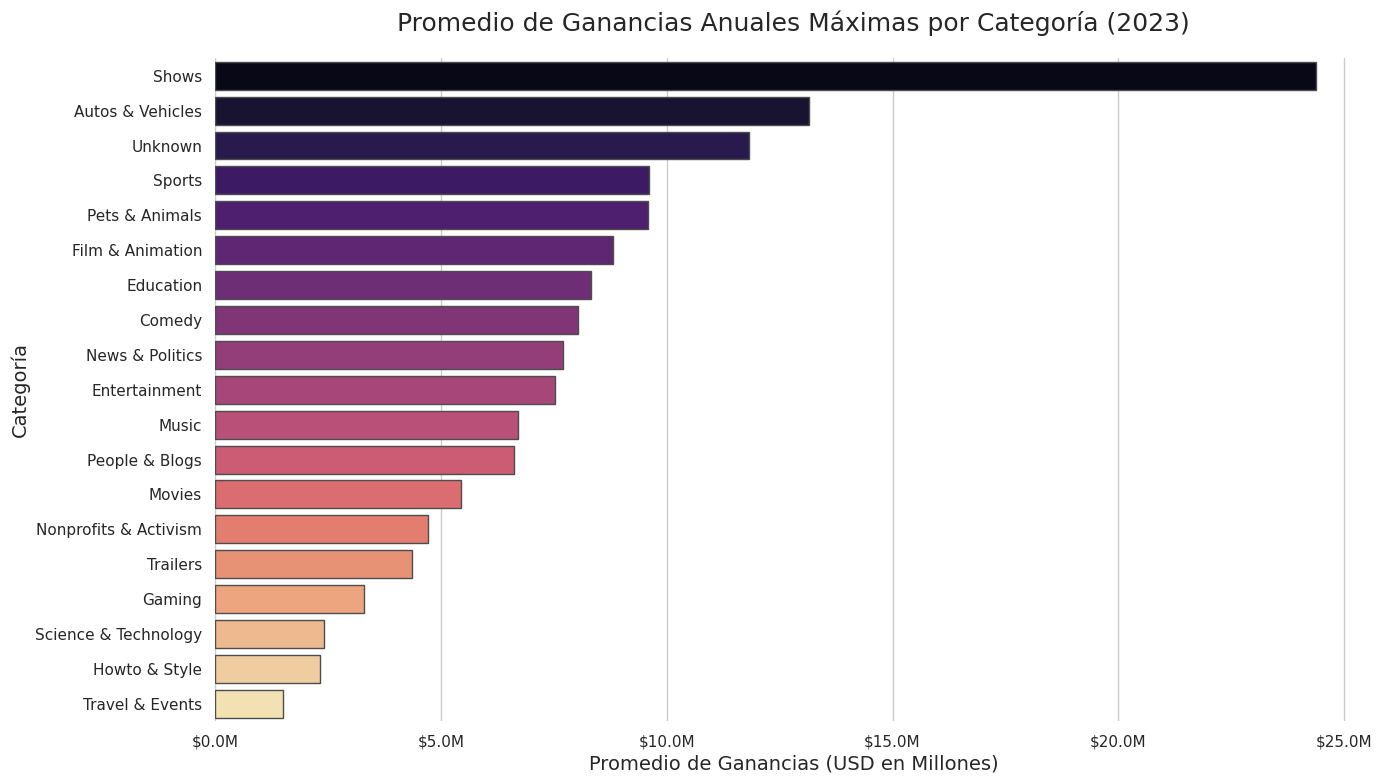

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

# 1. Creamos la carpeta 'visuals' si no existe
visuals_folder = 'visuals'
if not os.path.exists(visuals_folder):
    os.makedirs(visuals_folder)
    print(f"Carpeta '{visuals_folder}' creada con éxito.")
else:
    print(f"La carpeta '{visuals_folder}' ya existe.")

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Agrupamos por Categoría y calculamos el promedio de Ganancias Anuales
category_earnings = df_clean.groupby('Category')['Highest Yearly Earnings'].mean().sort_values(ascending=False).reset_index()

# Creamos el gráfico
chart = sns.barplot(x='Highest Yearly Earnings', y='Category', data=category_earnings, palette='magma', edgecolor='0.3')

# Formateamos el eje X para que sea legible (en Millones de USD)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:,.1f}M')
chart.xaxis.set_major_formatter(formatter)

plt.title('Promedio de Ganancias Anuales Máximas por Categoría (2023)', fontsize=18, pad=20)
plt.xlabel('Promedio de Ganancias (USD en Millones)', fontsize=14)
plt.ylabel('Categoría', fontsize=14)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('visuals/earnings_by_category.png', dpi=300, bbox_inches="tight")
plt.show()

In [14]:


# 1. Contamos cuántos "unknown" hay comparado con el resto
unknown_count = (df_clean['Category'] == 'Unknown').sum()
total_rows = len(df_clean)
print(f"Cantidad de 'Unknown' en la columna 'Category': {unknown_count}")
print(f"Total de filas en el dataset: {total_rows}")


Cantidad de 'Unknown' en la columna 'Category': 46
Total de filas en el dataset: 990


In [15]:
# 1. Filtramos el DataFrame para obtener solo las filas donde Category es 'Unknown'
# Usamos .head(10) para ver las primeras 10 ocurrencias
unknown_channels = df_clean[df_clean['Category'] == 'Unknown'].head(10)

# 2. Mostramos el resultado
print("Auditoría de Canales con Categoría 'Unknown':")
display(unknown_channels)

# 3. (Tip extra) ¿Qué porcentaje del total representan?
total_unknown = (df_clean['Category'] == 'Unknown').sum()
porcentaje = (total_unknown / len(df_clean)) * 100
print(f"\nNota para el portafolio: Hay {total_unknown} canales sin categoría ({porcentaje:.2f}% del dataset).")

Auditoría de Canales con Categoría 'Unknown':


,Youtuber,Subscribers,Video Views,Category,Uploads,Country,Highest Yearly Earnings,Created Year
5,Music,119000000,0,Unknown,0,Unknown,0,2013
12,Gaming,93600000,0,Unknown,0,Unknown,0,2013
18,Sports,75000000,0,Unknown,3,United States,1,2006
91,Vlad vï¿½ï¿½ï,37900000,"23,510,152,352",Unknown,515,United States,"11,700,000",2018
102,News,36300000,0,Unknown,0,Unknown,0,2013
132,BETER Bï¿½ï¿½,32700000,"19,180,039,918",Unknown,2738,Turkey,"70,200,000",2012
155,Diana and Roma ESP,30700000,"12,355,992,466",Unknown,578,United States,"4,900,000",2016
161,ýýýýýýýýýýýýýýý ýýýýýý ýýýýýýýýýýýýýýýýýý,30400000,"17,999,961,915",Unknown,532,United States,"5,900,000",2018
173,Popular on YouTube,29300000,0,Unknown,3,Unknown,0,2017
214,D Billions,26200000,"31,977,463,002",Unknown,775,United States,"23,400,000",2019



Nota para el portafolio: Hay 46 canales sin categoría (4.65% del dataset).


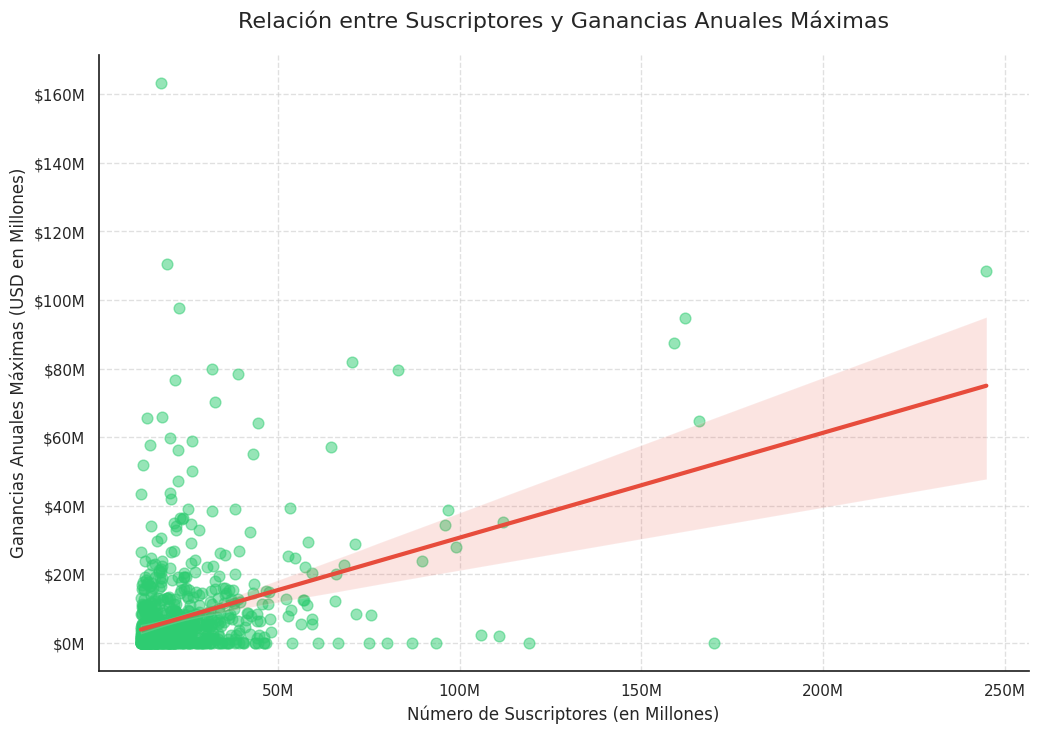

El Coeficiente de Correlación de Pearson es: 0.39


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Configuración de la figura
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# 2. Creación del Scatter Plot
# Usamos 'regplot' para que dibuje automáticamente la línea de tendencia
scatter = sns.regplot(
    data=df_clean,
    x='Subscribers',
    y='Highest Yearly Earnings',
    scatter_kws={'alpha':0.5, 's':60, 'color':'#2ecc71'}, # Puntos verdes semitransparentes
    line_kws={'color':'#e74c3c', 'lw':3} # Línea de tendencia roja
)

# 3. Formatear los ejes para que sean legibles ($M para dinero y M para subs)
formatter_money = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:,.0f}M')
formatter_subs = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.0f}M')

plt.gca().yaxis.set_major_formatter(formatter_money)
plt.gca().xaxis.set_major_formatter(formatter_subs)

# 4. Títulos y etiquetas
plt.title('Relación entre Suscriptores y Ganancias Anuales Máximas', fontsize=16, pad=20)
plt.xlabel('Número de Suscriptores (en Millones)', fontsize=12)
plt.ylabel('Ganancias Anuales Máximas (USD en Millones)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.savefig('visuals/subscribers_vs_earnings_scatter.png', dpi=300, bbox_inches="tight")
plt.show()

# 5. Cálculo matemático de la correlación (El toque de experto)
correlation = df_clean['Subscribers'].corr(df_clean['Highest Yearly Earnings'])
print(f"El Coeficiente de Correlación de Pearson es: {correlation:.2f}")

# ¿Calidad o Cantidad?

In [17]:
# Promedio de vistas por cada video subido
# Filtrando canales con 0 uploads

df_clean_filtered = df_clean[df_clean['Uploads'] > 0]
df_clean_filtered['Views Per Video'] = df_clean_filtered['Video Views'] / df_clean_filtered['Uploads']

# Francotiradores (más vistas con menos videos)

top_efficient = df_clean_filtered.sort_values(by='Views Per Video', ascending=False).head(10)
display(top_efficient)

/tmp/ipykernel_10991/523654254.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_filtered['Views Per Video'] = df_clean_filtered['Video Views'] / df_clean_filtered['Uploads']


,Youtuber,Subscribers,Video Views,Category,Uploads,Country,Highest Yearly Earnings,Created Year,Views Per Video
51,Bad Bunny,46100000,"30,686,342,319",Music,1,Unknown,0,2005,"30,686,342,319"
16,5-Minute Crafts,80100000,"26,236,790,209",Howto & Style,1,United Kingdom,0,2020,"26,236,790,209"
14,Goldmines,86900000,"24,118,230,580",Film & Animation,1,Unknown,1,2006,"24,118,230,580"
50,A4,46300000,"22,936,630,813",Gaming,1,Cuba,5,2006,"22,936,630,813"
77,LUCCAS NETO - LUCCAS TOON,39400000,"22,302,547,082",People & Blogs,1,Unknown,0,2021,"22,302,547,082"
48,Badabun,46800000,"19,398,045,702",Entertainment,1,Unknown,21,2007,"19,398,045,702"
220,Marï¿½ï¿½ï¿½ï¿½ï¿½,26000000,"18,597,534,412",Music,1,Unknown,0,2008,"18,597,534,412"
570,Alfredo Larin,16400000,"14,431,830,557",Entertainment,1,Unknown,0,2015,"14,431,830,557"
986,ANNA KOVA,12400000,"13,959,586,308",People & Blogs,1,Unknown,0,2006,"13,959,586,308"
569,RCTI - LAYAR DRAMA INDONESIA,16400000,"13,478,392,540",Entertainment,1,Unknown,0,2020,"13,478,392,540"


/tmp/ipykernel_10991/2899981609.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_efficient, x='Video Views', y='Youtuber', palette='viridis')


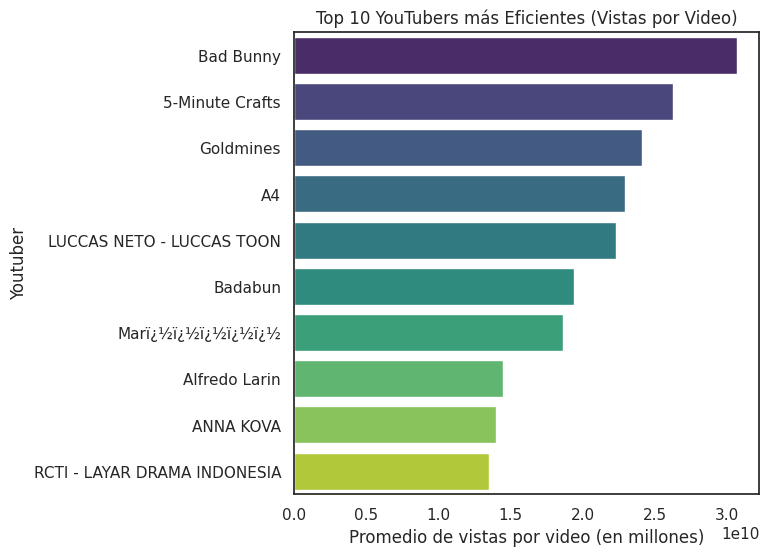

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6 ))
sns.barplot(data=top_efficient, x='Video Views', y='Youtuber', palette='viridis')
plt.title('Top 10 YouTubers más Eficientes (Vistas por Video)')
plt.xlabel('Promedio de vistas por video (en millones)')
plt.savefig('visuals/top_efficient_youtubers.png', dpi=300, bbox_inches="tight")
plt.show()

#EVOLUCIÓN DEL EXITO EN EL TIEMPO

In [19]:
# Filtramos a partir del año 2005 y agrupamos para calcular el promedio de suscriptores

df_time = df_clean[df_clean['Created Year'] >= 2005].groupby('Created Year')['Subscribers'].mean().reset_index()


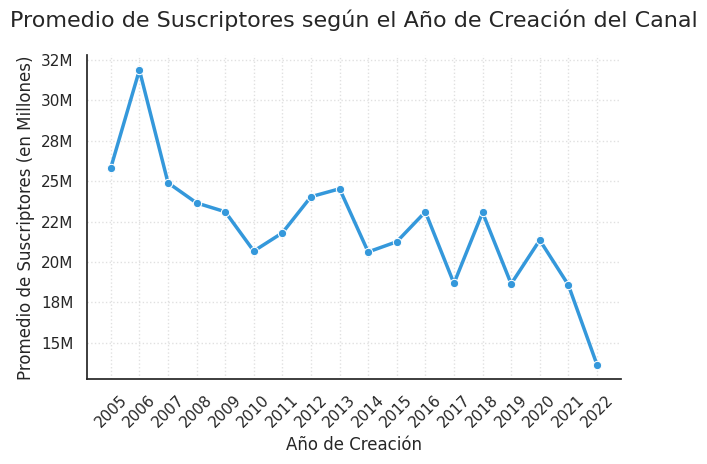

In [20]:
sns.lineplot(
    data=df_time,
    x='Created Year',
    y='Subscribers',
    marker='o',
    linewidth=2.5,
    color='#3498db'
)

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.0f}M'))

plt.title('Promedio de Suscriptores según el Año de Creación del Canal', fontsize=16, pad=20)
plt.xlabel('Año de Creación', fontsize=12)
plt.ylabel('Promedio de Suscriptores (en Millones)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(df_time['Created Year'], rotation=45) # Mostramos todos los años en el eje X
sns.despine()
plt.tight_layout()
plt.savefig('visuals/subscribers_over_time.png', dpi=300, bbox_inches="tight")
plt.show()

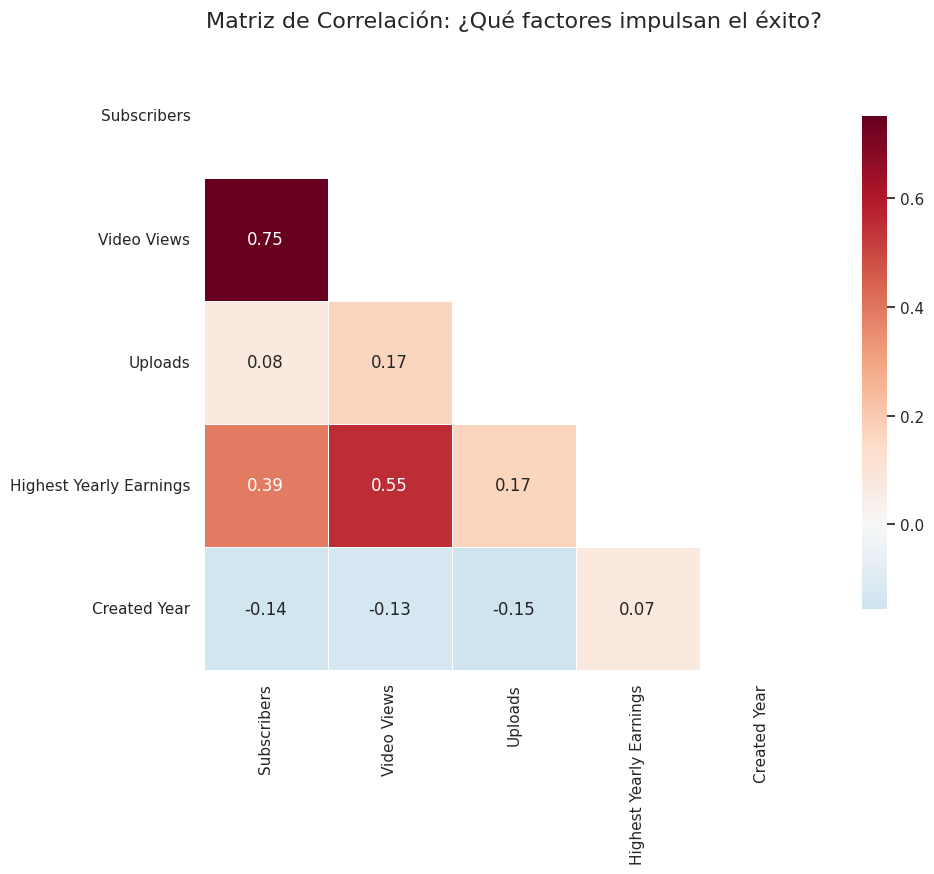

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Seleccionamos solo las columnas numéricas para la correlación
numeric_cols = [
    'Subscribers', 'Video Views', 'Uploads',
    'Highest Yearly Earnings', 'Created Year'
]

# Añadimos 'Views Per Video' solo si existe en tu dataframe
if 'Views Per Video' in df_clean.columns:
    numeric_cols.append('Views Per Video')

corr_matrix = df_clean[numeric_cols].corr()

# 2. Configuración de la figura
plt.figure(figsize=(10, 8))

# 3. Creamos el mapa de calor
# annot=True pone los números dentro de los cuadros
# cmap='RdBu_r' usa Rojo para positivo y Azul para negativo (muy estándar)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Máscara para ver solo la mitad (opcional, muy pro)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    mask=mask,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación: ¿Qué factores impulsan el éxito?', fontsize=16, pad=20)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.savefig('visuals/correlation_matrix.png', dpi=300, bbox_inches="tight")
plt.show()